# Métodos Numéricos para Encontrar Raízes
Esta aula aborda os métodos de Newton-Raphson e secante, com critérios de parada flexíveis.

In [45]:
import numpy as np
import matplotlib.pyplot as plt

## Função de exemplo
Vamos usar f(x) = 5x³ - 8x - 0.5 como exemplo.

In [42]:
def f(x):
    return x**2 + x - 6

## Gráfico da função

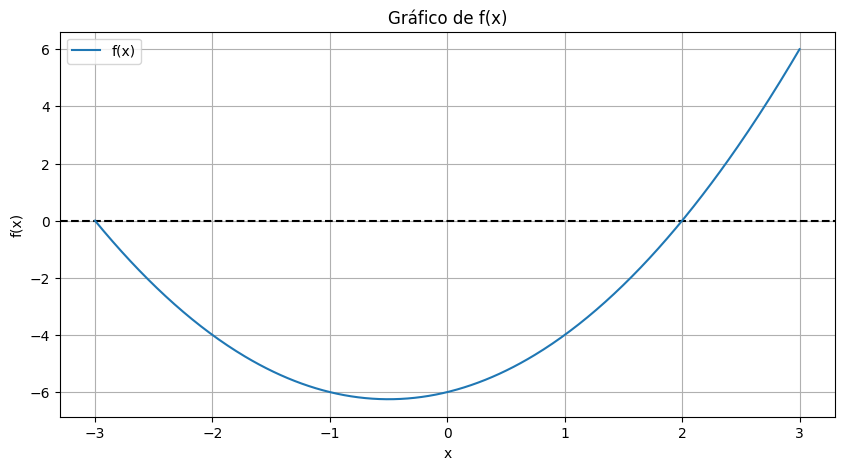

In [46]:
x_vals = np.linspace(-3, 3, 400)
y_vals = np.array([f(x) for x in x_vals])
plt.figure(figsize=(10,5))
plt.axhline(0, color='black', linestyle='--')
plt.plot(x_vals, y_vals, label='f(x)')
plt.title('Gráfico de f(x)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True)
plt.legend()
plt.show()

## Método da Bissecção com critérios flexíveis

In [47]:
def bissecao_flex(f, a, b, tol=1e-6, max_iter=100, mode='func'):
    if a > b:
        a, b = b, a
    fa, fb = f(a), f(b)
    if fa == 0:
        return a, [a]
    if fb == 0:
        return b, [b]
    if fa * fb > 0:
        raise ValueError('Intervalo não possui mudança de sinal.')
    historico = []
    p = None
    for _ in range(max_iter):
        p = 0.5 * (a + b)
        fp = f(p)
        historico.append(p)
        stop_func = abs(fp) < tol
        stop_intervalo = 0.5 * (b - a) < tol
        if mode == 'func' and stop_func:
            return p, historico
        if mode == 'intervalo' and stop_intervalo:
            return p, historico
        if mode == 'ambos' and (stop_func or stop_intervalo):
            return p, historico
        if fa * fp < 0:
            b, fb = p, fp
        else:
            a, fa = p, fp
    return p, historico

## Método de Newton-Raphson com dois critérios de parada

In [48]:
def newton_raphson_duplo_criterio(f, df, x0, eps1=1e-6, eps2=1e-6, max_iter=50):
    x = x0
    historico = [x0]
    for k in range(max_iter):
        fx = f(x)
        dfx = df(x)
        if dfx == 0:
            raise ZeroDivisionError('Derivada zero. Método falhou.')
        x_new = x - fx/dfx
        historico.append(x_new)
        crit1 = abs(f(x_new)) < eps1
        crit2 = abs(x_new - x) < eps2
        if crit1:
            return x_new, historico, k+1, 'funcional (|f(x)| < eps1)'
        if crit2:
            return x_new, historico, k+1, 'intervalar (|x_{k+1} - x_k| < eps2)'
        x = x_new
    return x, historico, max_iter, 'máximo de iterações'

## Método da Secante com dois critérios de parada

In [49]:
def secante_duplo_criterio(f, x0, x1, eps1=1e-6, eps2=1e-6, max_iter=50):
    historico = [x0, x1]
    for k in range(max_iter):
        fx0, fx1 = f(x0), f(x1)
        denom = fx1 - fx0
        if denom == 0:
            raise ZeroDivisionError('Secante falhou: f(x1) - f(x0) = 0.')
        x2 = x1 - fx1 * (x1 - x0) / denom
        historico.append(x2)
        crit1 = abs(f(x2)) < eps1
        crit2 = abs(x2 - x1) < eps2
        print(f"x{k+2} = {x2}")
        if crit1:
            return x2, historico, k+1, 'funcional (|f(x)| < eps1)'
        if crit2:
            return x2, historico, k+1, 'intervalar (|x_{k+1} - x_k| < eps2)'
        x0, x1 = x1, x2
    return x2, historico, max_iter, 'máximo de iterações'

## Exemplos de uso
![image.png](attachment:image.png)

In [50]:
# Exemplo do slide: f(x) = x^2 + x - 6, x0=1.5, x1=1.7, eps1=-3, eps2=2
def f(x):
    return x**2 + x - 6

# Parâmetros do exemplo
x0 = 1.5
x1 = 1.7
eps1 = -3
eps2 = 2

max_iter = 10
historico = [x0, x1]
print(f"x0 = {x0:.4f}, f(x0) = {f(x0):.4f}")
print(f"x1 = {x1:.4f}, f(x1) = {f(x1):.4f}")
for k in range(max_iter):
    fx0, fx1 = f(x0), f(x1)
    denom = fx1 - fx0
    if denom == 0:
        print('Denominador zero')
        break
    x2 = x1 - fx1 * (x1 - x0) / denom
    historico.append(x2)
    print(f"x{k+2} = {x2}")
    crit1 = abs(f(x2)) < eps1
    crit2 = abs(x2 - x1) < eps2
    # if crit1:
    #     print(x2, k+1, 'crit1 (|f(x)| < eps1)')
    # if crit2:
    #     print(x2, k+1, 'crit2 (|x_{k+1} - x_k| < eps2)')
    # print(f"x{k+2} = {x2:.4f}  |  Numerador: {x1:.4f}*{fx1:.4f} - {x0:.4f}*{fx0:.4f}  |  Denominador: {fx1:.4f} - {fx0:.4f}")
    # print(f"         = {x1*fx1 - x0*fx0:.4f} / {denom:.4f}  =>  x{k+2} = {x2:.4f}")
    # print(f"f(x{k+2}) = {f(x2):.4f}\n")
    x0, x1 = x1, x2
print(f"Histórico: {historico}")

x0 = 1.5000, f(x0) = -2.2500
x1 = 1.7000, f(x1) = -1.4100
x2 = 2.0357142857142856
x3 = 1.997737556561086
x4 = 1.9999839470896073
x5 = 2.000000007267072
x6 = 1.9999999999999767
x7 = 2.0
x8 = 2.0
Denominador zero
Histórico: [1.5, 1.7, 2.0357142857142856, 1.997737556561086, 1.9999839470896073, 2.000000007267072, 1.9999999999999767, 2.0, 2.0]


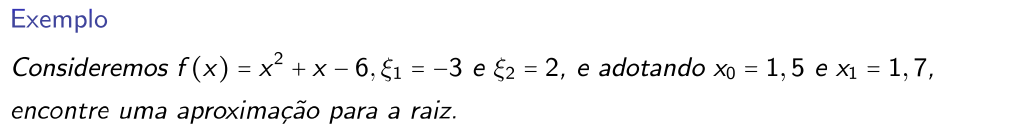

In [ ]:
# Secante
raiz, hist, iter_stop, crit_stop = secante_duplo_criterio(f, -1.5, -1.7)
print(f'Secante: raiz ≈ {raiz}, histórico: {hist}')
print(f'Parou na iteração: {iter_stop} pelo critério: {crit_stop}')

x2 = -3.8863636363636385
x3 = -2.748761149653122
x4 = -2.9604819787590384
x5 = -3.002108292554415
x6 = -2.999983211277701
x7 = -2.9999999929238523
Secante: raiz ≈ -2.9999999929238523, histórico: [-1.5, -1.7, -3.8863636363636385, -2.748761149653122, -2.9604819787590384, -3.002108292554415, -2.999983211277701, -2.9999999929238523]
Parou na iteração: 6 pelo critério: funcional (|f(x)| < eps1)


: 